# Optimización de `JaimeContrarianStrategy`

Grid search, random search y walk-forward sobre los parámetros más sensibles.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100

# 1. Datos

In [2]:
from src.io import IO, YFinanceProvider
from src.domain.asset import PriceHistory
from src.domain.portfolio import Portfolio

universe = IO().load_universe('jaime')
prices = YFinanceProvider().get_prices(universe.tickers, start='2010-01-01', end='2025-12-01')
history = PriceHistory(universe, prices)

DEFENSIVE = 'XEON.DE'
WARMUP = 504  # cubre cov largo (252) + trend (200) + skip (21)

print(f'Period: {history.dates[0].date()} -> {history.dates[-1].date()} ({len(history)} days)')

[*********************100%***********************]  21 of 21 completed
BOTZ: 1794 missing days (43.6%)
CIBR: 1494 missing days (36.3%)
DBA: 109 missing days (2.7%)
GLD: 109 missing days (2.7%)
IEF: 109 missing days (2.7%)
IEMA.L: 91 missing days (2.2%)
ITB: 109 missing days (2.7%)
IUSN.DE: 2180 missing days (53.0%)
IWDA.L: 91 missing days (2.2%)
LIT: 248 missing days (6.0%)
SLV: 109 missing days (2.7%)
SOXX: 109 missing days (2.7%)
TLT: 109 missing days (2.7%)
XEON.DE: 66 missing days (1.6%)
XLE: 109 missing days (2.7%)
XLF: 109 missing days (2.7%)
XLI: 109 missing days (2.7%)
XLK: 109 missing days (2.7%)
XLP: 109 missing days (2.7%)
XLU: 109 missing days (2.7%)
XLV: 109 missing days (2.7%)


Period: 2018-04-26 -> 2025-11-28 (1854 days)


In [3]:
from src.strategy.jaime_contrarian import JaimeContrarianStrategy

BASE_KWARGS = {
    'defensive_ticker': DEFENSIVE,
    'rebalance_every': 21,
}

# 2. Grid search

Espacio pequeño sobre los 4 parámetros más influyentes: aversión al riesgo (`gamma`), agresividad de las views (`view_scale`), tamaño del top-N y banda DN base.

In [4]:
from src.backtesting import GridSearchOptimizer, ParameterGrid

grid_optimizer = GridSearchOptimizer(
    strategy_cls=JaimeContrarianStrategy,
    param_grid=ParameterGrid({
        'gamma':       [-1.5, -0.8, -0.3],
        'view_scale':  [0.10, 0.28, 0.50],
        'top_n':       [10, 20, 30],
        'base_band':   [0.03, 0.05, 0.08],
    }),
    metric='sharpe_ratio',
    warmup_size=WARMUP,
    base_strategy_kwargs=BASE_KWARGS,
)

grid_result = grid_optimizer.optimize(
    universe=universe,
    history=history,
    portfolio_factory=lambda: Portfolio(initial_cash=10_000_000),
)

[1/81] Testing {'gamma': -1.5, 'view_scale': 0.1, 'top_n': 10, 'base_band': 0.03}
  New best: sharpe_ratio=1.1492
[2/81] Testing {'gamma': -1.5, 'view_scale': 0.1, 'top_n': 10, 'base_band': 0.05}
[3/81] Testing {'gamma': -1.5, 'view_scale': 0.1, 'top_n': 10, 'base_band': 0.08}
[4/81] Testing {'gamma': -1.5, 'view_scale': 0.1, 'top_n': 20, 'base_band': 0.03}
[5/81] Testing {'gamma': -1.5, 'view_scale': 0.1, 'top_n': 20, 'base_band': 0.05}
[6/81] Testing {'gamma': -1.5, 'view_scale': 0.1, 'top_n': 20, 'base_band': 0.08}
[7/81] Testing {'gamma': -1.5, 'view_scale': 0.1, 'top_n': 30, 'base_band': 0.03}
[8/81] Testing {'gamma': -1.5, 'view_scale': 0.1, 'top_n': 30, 'base_band': 0.05}
[9/81] Testing {'gamma': -1.5, 'view_scale': 0.1, 'top_n': 30, 'base_band': 0.08}
[10/81] Testing {'gamma': -1.5, 'view_scale': 0.28, 'top_n': 10, 'base_band': 0.03}
  New best: sharpe_ratio=1.2818
[11/81] Testing {'gamma': -1.5, 'view_scale': 0.28, 'top_n': 10, 'base_band': 0.05}
[12/81] Testing {'gamma': -1.5

In [5]:
print(f'Best params: {grid_result.best_params}')
print(f'Best {grid_optimizer.metric}: {grid_result.best_metric:.4f}')
print()

grid_df = pd.DataFrame([
    {**params, grid_optimizer.metric: metric}
    for params, metric in grid_result.all_results
]).sort_values(grid_optimizer.metric, ascending=False)

grid_df.head(15)

Best params: {'gamma': -0.3, 'view_scale': 0.5, 'top_n': 10, 'base_band': 0.03}
Best sharpe_ratio: 1.3186



,gamma,view_scale,top_n,base_band,sharpe_ratio
74,-0.3,0.50,10,0.08,1.318627
73,-0.3,0.50,10,0.05,1.318627
72,-0.3,0.50,10,0.03,1.318627
63,-0.3,0.28,10,0.03,1.313201
64,-0.3,0.28,10,0.05,1.313201
65,-0.3,0.28,10,0.08,1.313201
45,-0.8,0.50,10,0.03,1.309906
46,-0.8,0.50,10,0.05,1.309906
47,-0.8,0.50,10,0.08,1.309906
18,-1.5,0.50,10,0.03,1.303338


Period:                2020-05-26 -> 2025-11-28 (1350 days)
Initial value:         $10,000,000.00 (cash=$10,000,000.00)
Final value:           $24,292,966.58
Total return:          142.93%
Annualized return:     18.02%
Annualized vol:        13.67%
Sharpe ratio:          1.3186
Max drawdown:          -13.97%
Calmar ratio:          1.2895
Total costs:           $152,140.71
Signals:               1183
Orders:                1183 (accepted=830, rejected=0, invalid=353)
Trades:                830


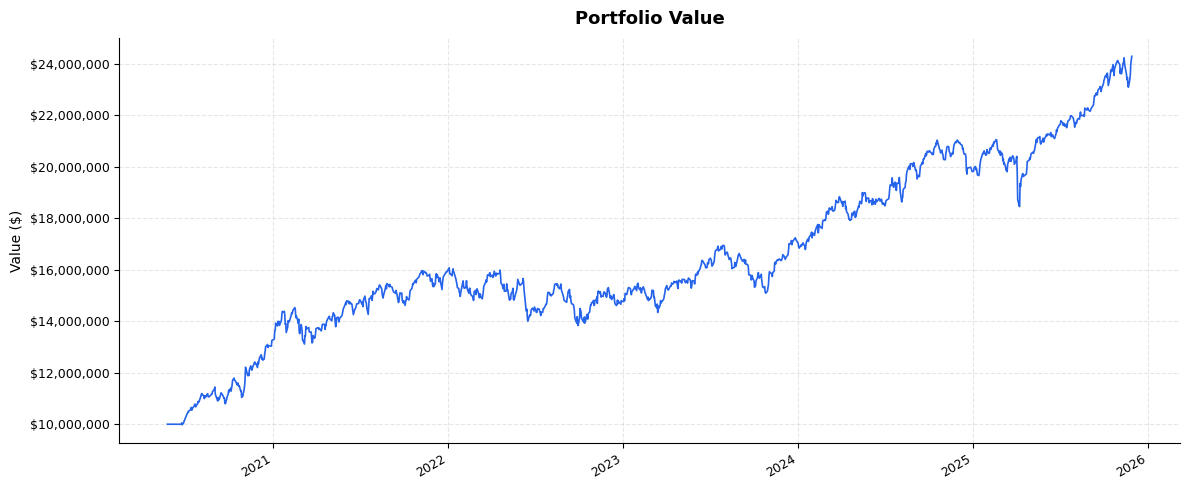

/Users/hyx/miniconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


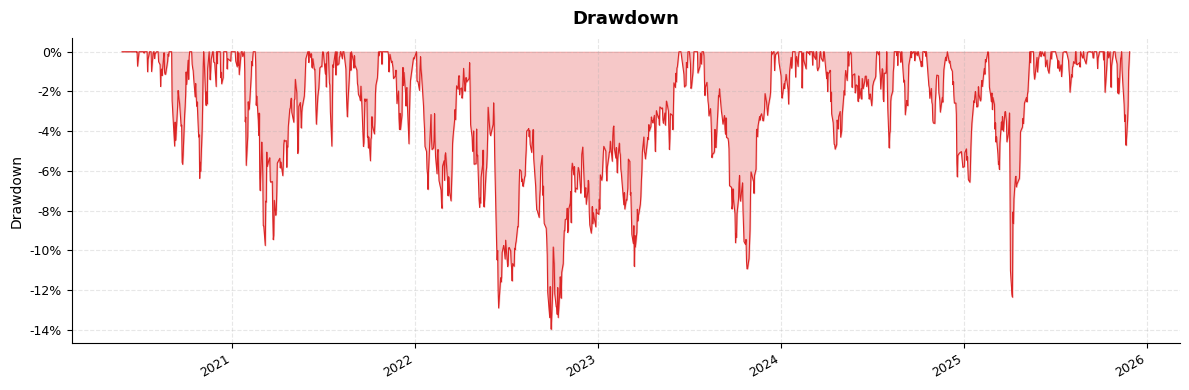

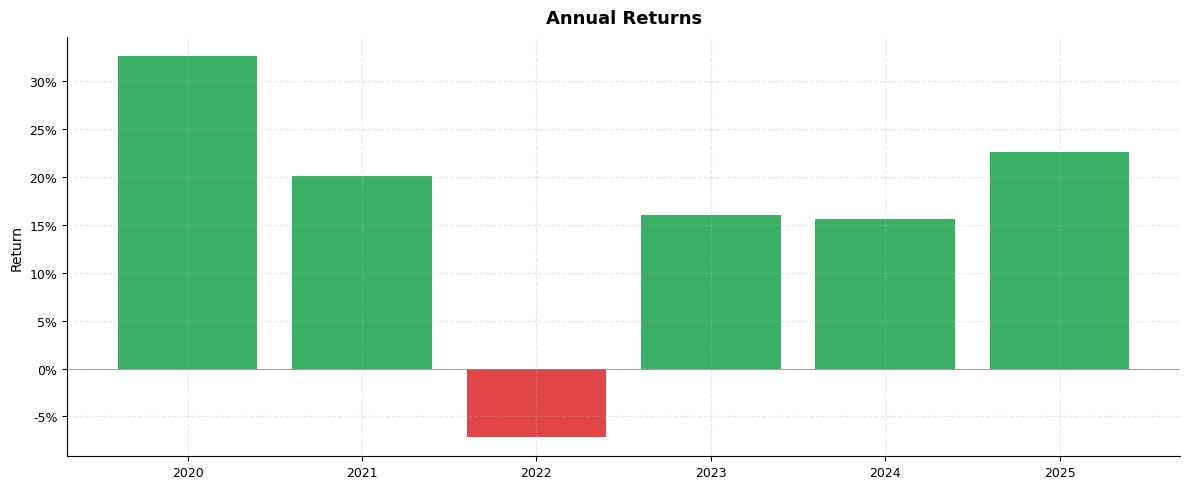

In [6]:
if grid_result.best_backtest:
    grid_result.best_backtest.print_summary()
    grid_result.best_backtest.plot_value()
    grid_result.best_backtest.plot_drawdown()
    grid_result.best_backtest.plot_annual_returns()

# 3. Random search

Espacio más amplio cubriendo también constraints, BL y rebalanceo. 40 muestras.

In [18]:
from src.backtesting import RandomParameterGrid

random_optimizer = GridSearchOptimizer(
    strategy_cls=JaimeContrarianStrategy,
    param_grid=RandomParameterGrid(
        {
            'gamma':                 [-2.0, -1.5, -1.0, -0.8, -0.5, -0.3, 0.3, 0.5],
            'view_scale':            [0.05, 0.10, 0.15, 0.20, 0.28, 0.40, 0.60],
            'top_n':                 [5, 10, 15, 20, 25, 30],
            'max_individual_weight': [0.20, 0.30, 0.40, 0.50],
            'max_sector_weight':     [0.25, 0.35, 0.50, 0.75],
            'base_band':             [0.02, 0.03, 0.05, 0.08, 0.12],
            'bl_risk_aversion':      [1.5, 2.5, 3.5],
            'bl_tau':                [0.025, 0.05, 0.10],
            'rebalance_every':       [1, 2, 5, 10, 21, 42, 63],
        },
        n_samples=40,
        seed=42,
    ),
    metric='sharpe_ratio',
    warmup_size=WARMUP,
    base_strategy_kwargs=BASE_KWARGS,
)

random_result = random_optimizer.optimize(
    universe=universe,
    history=history,
    portfolio_factory=lambda: Portfolio(initial_cash=10_000_000),
)

[1/40] Testing {'gamma': -1.5, 'view_scale': 0.05, 'top_n': 30, 'max_individual_weight': 0.4, 'max_sector_weight': 0.35, 'base_band': 0.03, 'bl_risk_aversion': 1.5, 'bl_tau': 0.1, 'rebalance_every': 1}
  New best: sharpe_ratio=0.9484
[2/40] Testing {'gamma': -1.5, 'view_scale': 0.28, 'top_n': 20, 'max_individual_weight': 0.2, 'max_sector_weight': 0.25, 'base_band': 0.02, 'bl_risk_aversion': 1.5, 'bl_tau': 0.025, 'rebalance_every': 21}
  New best: sharpe_ratio=1.2814
[3/40] Testing {'gamma': -2.0, 'view_scale': 0.28, 'top_n': 10, 'max_individual_weight': 0.5, 'max_sector_weight': 0.35, 'base_band': 0.08, 'bl_risk_aversion': 3.5, 'bl_tau': 0.05, 'rebalance_every': 63}
[4/40] Testing {'gamma': -2.0, 'view_scale': 0.6, 'top_n': 10, 'max_individual_weight': 0.5, 'max_sector_weight': 0.5, 'base_band': 0.05, 'bl_risk_aversion': 1.5, 'bl_tau': 0.025, 'rebalance_every': 63}
[5/40] Testing {'gamma': -0.3, 'view_scale': 0.05, 'top_n': 5, 'max_individual_weight': 0.5, 'max_sector_weight': 0.25, 'b

In [19]:
print(f'Best params: {random_result.best_params}')
print(f'Best {random_optimizer.metric}: {random_result.best_metric:.4f}')
print()

random_df = pd.DataFrame([
    {**params, random_optimizer.metric: metric}
    for params, metric in random_result.all_results
]).sort_values(random_optimizer.metric, ascending=False)

random_df.head(15)

Best params: {'gamma': -0.3, 'view_scale': 0.15, 'top_n': 10, 'max_individual_weight': 0.4, 'max_sector_weight': 0.35, 'base_band': 0.05, 'bl_risk_aversion': 2.5, 'bl_tau': 0.025, 'rebalance_every': 42}
Best sharpe_ratio: 1.3499



,gamma,view_scale,top_n,max_individual_weight,max_sector_weight,base_band,bl_risk_aversion,bl_tau,rebalance_every,sharpe_ratio
34,-0.3,0.15,10,0.4,0.35,0.05,2.5,0.025,42,1.349889
8,-0.3,0.15,10,0.4,0.25,0.12,3.5,0.025,21,1.292484
1,-1.5,0.28,20,0.2,0.25,0.02,1.5,0.025,21,1.281411
25,-0.3,0.20,20,0.5,0.25,0.02,1.5,0.050,42,1.271027
39,-0.3,0.10,30,0.4,0.75,0.05,1.5,0.025,42,1.237550
36,-1.5,0.28,10,0.4,0.35,0.05,1.5,0.025,5,1.215974
32,-1.0,0.05,25,0.2,0.35,0.02,3.5,0.025,42,1.207674
20,0.3,0.10,25,0.3,0.50,0.08,3.5,0.100,5,1.183944
13,-1.0,0.28,20,0.2,0.25,0.02,1.5,0.100,2,1.182658
28,-2.0,0.40,25,0.2,0.25,0.03,1.5,0.050,10,1.172468


Period:                2020-05-26 -> 2025-11-28 (1350 days)
Initial value:         $10,000,000.00 (cash=$10,000,000.00)
Final value:           $24,291,437.68
Total return:          142.91%
Annualized return:     18.02%
Annualized vol:        13.35%
Sharpe ratio:          1.3499
Max drawdown:          -12.99%
Calmar ratio:          1.3874
Total costs:           $98,297.28
Signals:               612
Orders:                612 (accepted=456, rejected=0, invalid=156)
Trades:                456


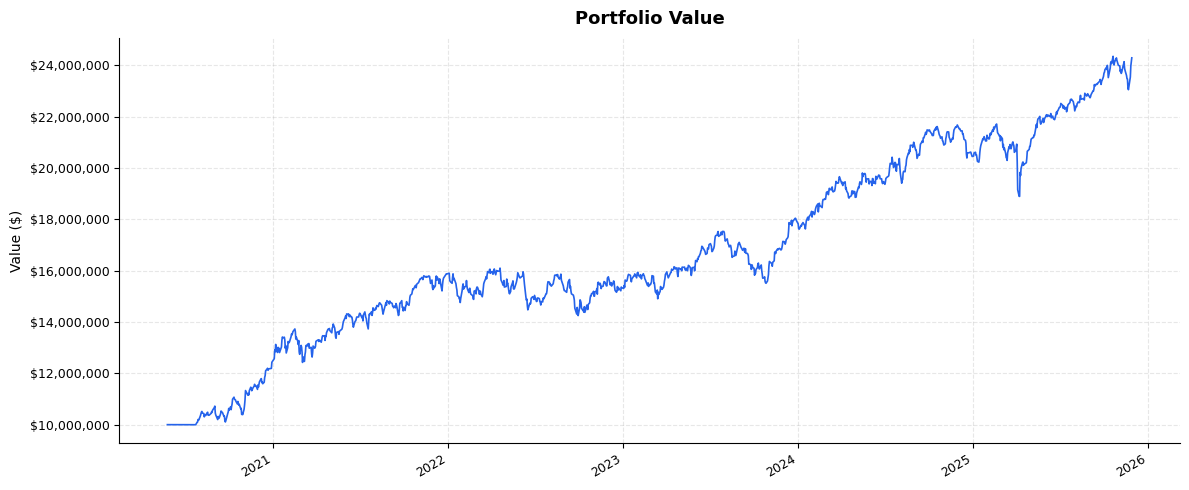

/Users/hyx/miniconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


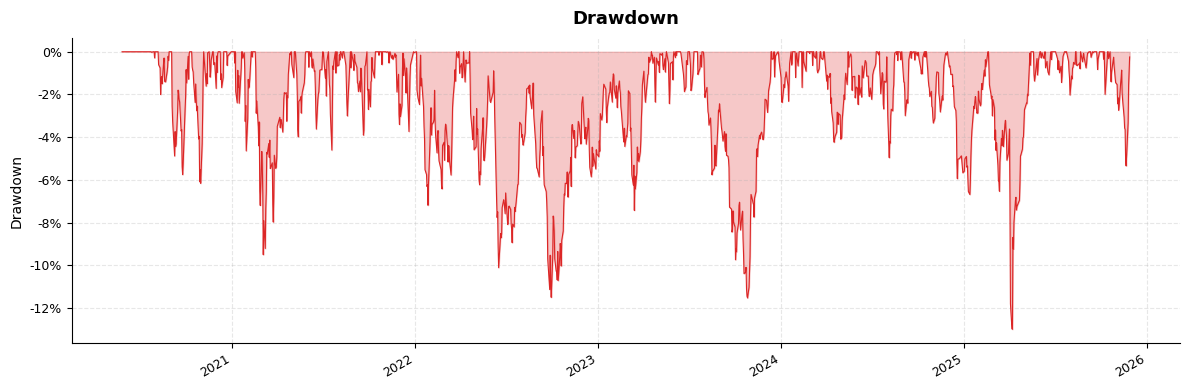

In [20]:
if random_result.best_backtest:
    random_result.best_backtest.print_summary()
    random_result.best_backtest.plot_value()
    random_result.best_backtest.plot_drawdown()

# 4. Walk-forward

Verifica que los parámetros encontrados son robustos. `OOS/IS ratio >= 0.6` es buena señal.

In [21]:
from src.backtesting import WalkForwardOptimizer

wf_optimizer = WalkForwardOptimizer(
    strategy_cls=JaimeContrarianStrategy,
    param_grid=ParameterGrid({
        'gamma':      [-1.5, -0.8, -0.3],
        'view_scale': [0.10, 0.28, 0.50],
        'top_n':      [10, 20],
    }),
    metric='sharpe_ratio',
    train_size=504,   # 2 años train
    test_size=126,    # 6 meses test
    step_size=126,    # ventanas no solapadas
    base_strategy_kwargs=BASE_KWARGS,
)

wf_result = wf_optimizer.run(
    universe=universe,
    full_history=history,
    portfolio_factory=lambda: Portfolio(initial_cash=10_000_000),
)

Walk-Forward: 10 windows, 18 combos each
Window 1/10
[1/18] Testing {'gamma': -1.5, 'view_scale': 0.1, 'top_n': 10}
  New best: sharpe_ratio=0.3731
[2/18] Testing {'gamma': -1.5, 'view_scale': 0.1, 'top_n': 20}
  New best: sharpe_ratio=0.4980
[3/18] Testing {'gamma': -1.5, 'view_scale': 0.28, 'top_n': 10}
  New best: sharpe_ratio=0.5875
[4/18] Testing {'gamma': -1.5, 'view_scale': 0.28, 'top_n': 20}
  New best: sharpe_ratio=0.6384
[5/18] Testing {'gamma': -1.5, 'view_scale': 0.5, 'top_n': 10}
[6/18] Testing {'gamma': -1.5, 'view_scale': 0.5, 'top_n': 20}
  New best: sharpe_ratio=0.6589
[7/18] Testing {'gamma': -0.8, 'view_scale': 0.1, 'top_n': 10}
[8/18] Testing {'gamma': -0.8, 'view_scale': 0.1, 'top_n': 20}
[9/18] Testing {'gamma': -0.8, 'view_scale': 0.28, 'top_n': 10}
[10/18] Testing {'gamma': -0.8, 'view_scale': 0.28, 'top_n': 20}
  New best: sharpe_ratio=0.7020
[11/18] Testing {'gamma': -0.8, 'view_scale': 0.5, 'top_n': 10}
[12/18] Testing {'gamma': -0.8, 'view_scale': 0.5, 'top_

In [22]:
print(f'Windows: {len(wf_result.windows)}')
print(f'OOS/IS ratio: {wf_result.oos_is_ratio:.2f}' if wf_result.oos_is_ratio is not None else 'OOS/IS ratio: N/A')
print('\nCombined OOS metrics:')
for k, v in wf_result.combined_metrics.items():
    print(f'  {k}: {v:.4f}')

Windows: 10
OOS/IS ratio: 0.16

Combined OOS metrics:
  total_return: 0.1096
  annualized_return: 0.0210
  annualized_volatility: 0.1678
  sharpe_ratio: 0.1253
  max_drawdown: -0.3166
  calmar_ratio: 0.0664


In [23]:
wf_result.params_over_time

,window,test_start,test_end,train_metric,gamma,view_scale,top_n
0,0,2020-10-05,2021-04-12,0.728793,-0.3,0.28,20
1,1,2021-04-13,2021-10-13,0.849548,-0.3,0.10,20
2,2,2021-10-14,2022-04-21,1.203114,-1.5,0.10,10
3,3,2022-04-22,2022-10-27,1.676561,-0.3,0.50,10
4,4,2022-10-28,2023-05-04,0.189234,-0.8,0.10,10
5,5,2023-05-05,2023-11-06,0.011473,-0.8,0.10,10
6,6,2023-11-07,2024-05-14,0.041243,-0.8,0.10,10
7,7,2024-05-15,2024-11-13,0.811869,-0.3,0.28,20
8,8,2024-11-14,2025-05-28,1.350320,-1.5,0.28,20
9,9,2025-05-29,2025-11-28,1.004007,-0.3,0.10,10


In [24]:
wf_result.summary()

,window,train_start,train_end,test_start,test_end,train_metric,test_return,test_sharpe,param_gamma,param_view_scale,param_top_n
0,0,2018-09-07,2020-10-02,2020-10-05,2021-04-12,0.728793,0.198342,2.086861,-0.3,0.28,20
1,1,2019-03-18,2021-04-12,2021-04-13,2021-10-13,0.849548,0.045145,0.807555,-0.3,0.10,20
2,2,2019-09-23,2021-10-13,2021-10-14,2022-04-21,1.203114,-0.048429,-0.699845,-1.5,0.10,10
3,3,2020-03-30,2022-04-21,2022-04-22,2022-10-27,1.676561,-0.026196,-0.331664,-0.3,0.50,10
4,4,2020-10-05,2022-10-27,2022-10-28,2023-05-04,0.189234,-0.004599,-0.076276,-0.8,0.10,10
5,5,2021-04-13,2023-05-04,2023-05-05,2023-11-06,0.011473,-0.009712,-0.165806,-0.8,0.10,10
6,6,2021-10-14,2023-11-06,2023-11-07,2024-05-14,0.041243,0.126396,3.052965,-0.8,0.10,10
7,7,2022-04-22,2024-05-14,2024-05-15,2024-11-13,0.811869,0.089535,1.826765,-0.3,0.28,20
8,8,2022-10-28,2024-11-13,2024-11-14,2025-05-28,1.350320,0.024172,0.320568,-1.5,0.28,20
9,9,2023-05-05,2025-05-28,2025-05-29,2025-11-28,1.004007,0.109638,2.479005,-0.3,0.10,10


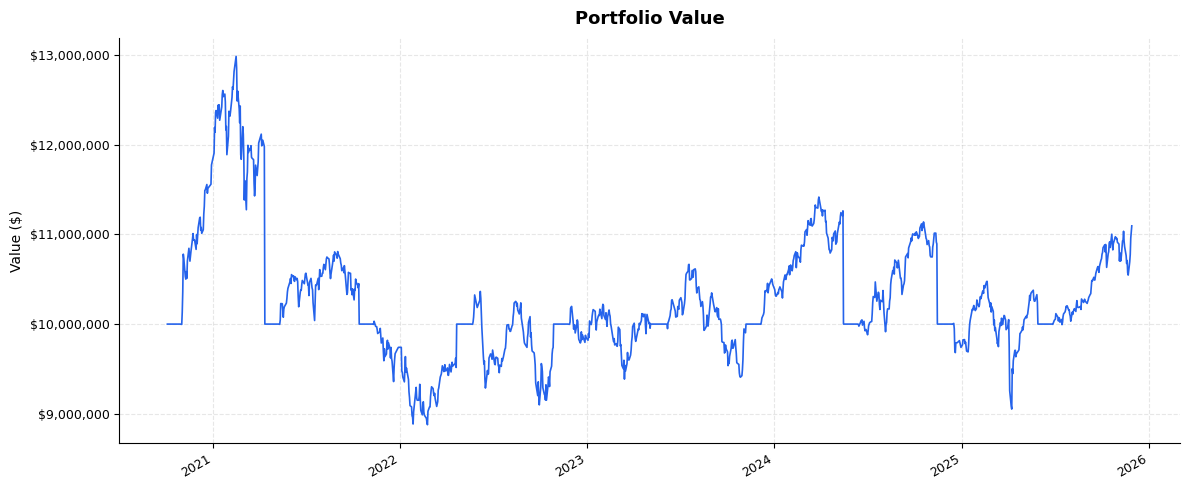

/Users/hyx/miniconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


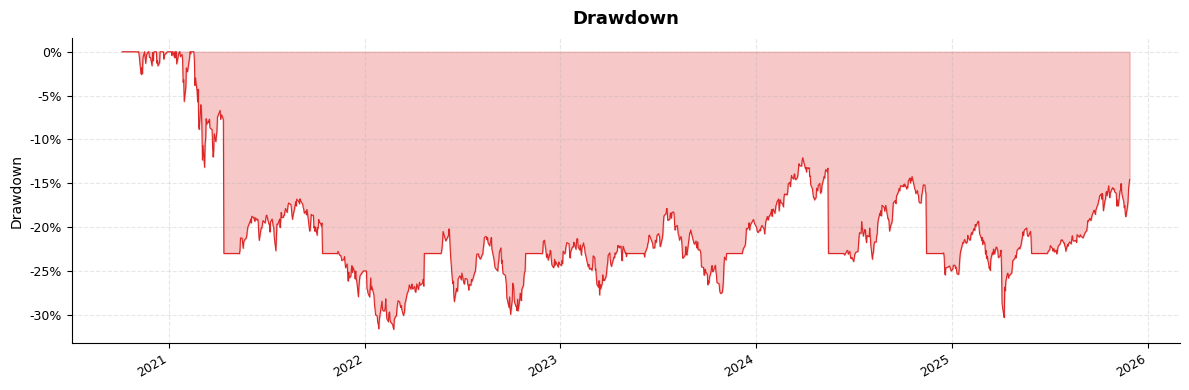

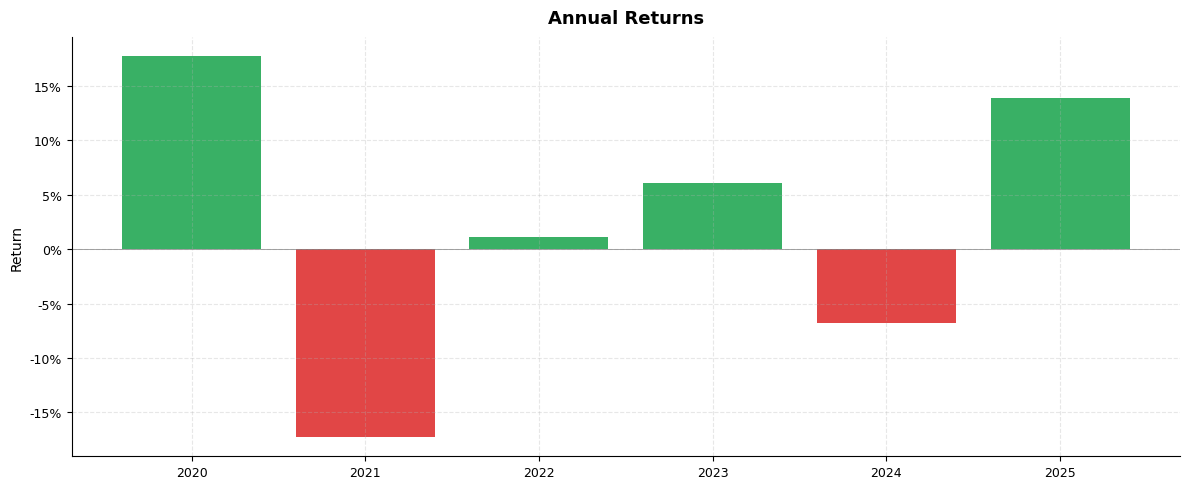

In [25]:
wf_result.combined.plot_value()
wf_result.combined.plot_drawdown()
wf_result.combined.plot_annual_returns()

# 5. Comparativa final: best grid vs best random vs Jaime default vs Buy & Hold

In [26]:
from src.strategy.buy_and_hold import BuyAndHoldStrategy
from src.backtesting import Backtest

best_grid = JaimeContrarianStrategy(
    universe=universe,
    name='jaime_grid_best',
    **{**BASE_KWARGS, **grid_result.best_params},
)

best_random = JaimeContrarianStrategy(
    universe=universe,
    name='jaime_random_best',
    **{**BASE_KWARGS, **random_result.best_params},
)

jaime_default = JaimeContrarianStrategy(
    universe=universe,
    name='jaime_default',
    **BASE_KWARGS,
)

bnh = BuyAndHoldStrategy(universe=universe, exclude=[DEFENSIVE])
bnh_rebal = BuyAndHoldStrategy(universe=universe, exclude=[DEFENSIVE], rebalance_every=21,
                                name='equal_weight_rebal')

comparison = Backtest(
    portfolio=Portfolio(initial_cash=10_000_000),
    universe=universe,
    strategies=[best_grid, best_random, jaime_default, bnh, bnh_rebal],
    history=history,
    warmup_size=WARMUP,
).run()

comparison.summary_df[[
    'total_return', 'annualized_return', 'annualized_volatility',
    'sharpe_ratio', 'max_drawdown', 'calmar_ratio', 'total_costs',
]].round(4)

,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,calmar_ratio,total_costs
jaime_grid_best,1.4293,0.1802,0.1367,1.3186,-0.1397,1.2895,152140.7134
jaime_random_best,1.4291,0.1802,0.1335,1.3499,-0.1299,1.3874,98297.2795
jaime_default,1.3694,0.1747,0.1375,1.2705,-0.1431,1.2206,151150.7101
buy_and_hold,1.1876,0.1573,0.1440,1.0927,-0.2145,0.7334,2704.6470
equal_weight_rebal,1.2082,0.1594,0.1328,1.1998,-0.2060,0.7738,12561.9810


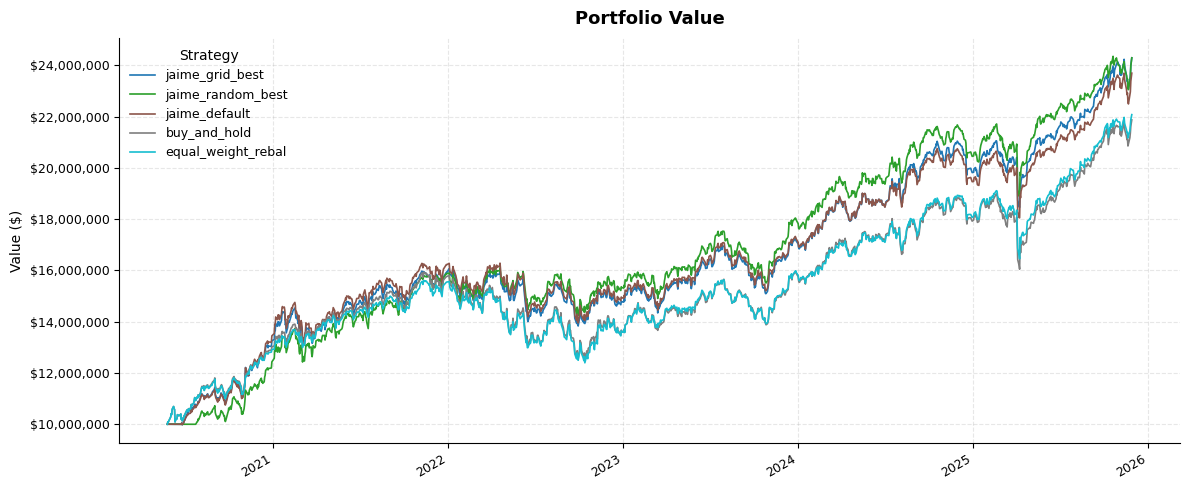

/Users/hyx/miniconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


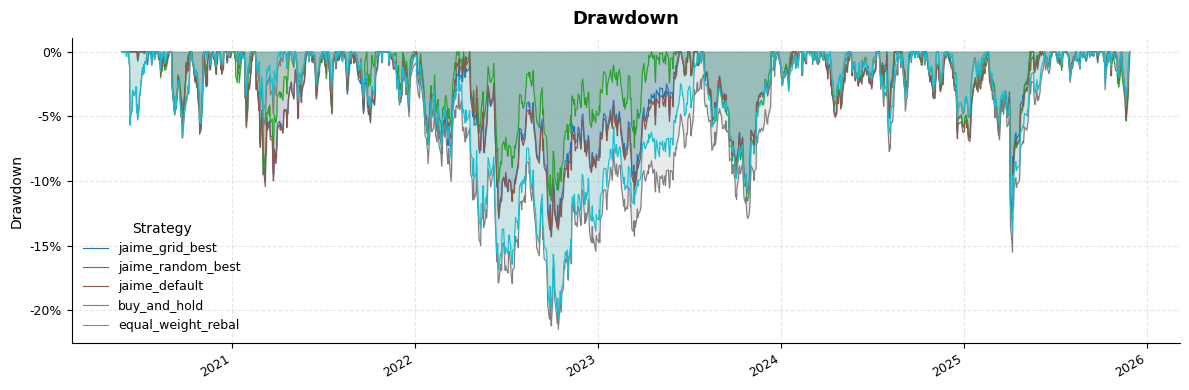

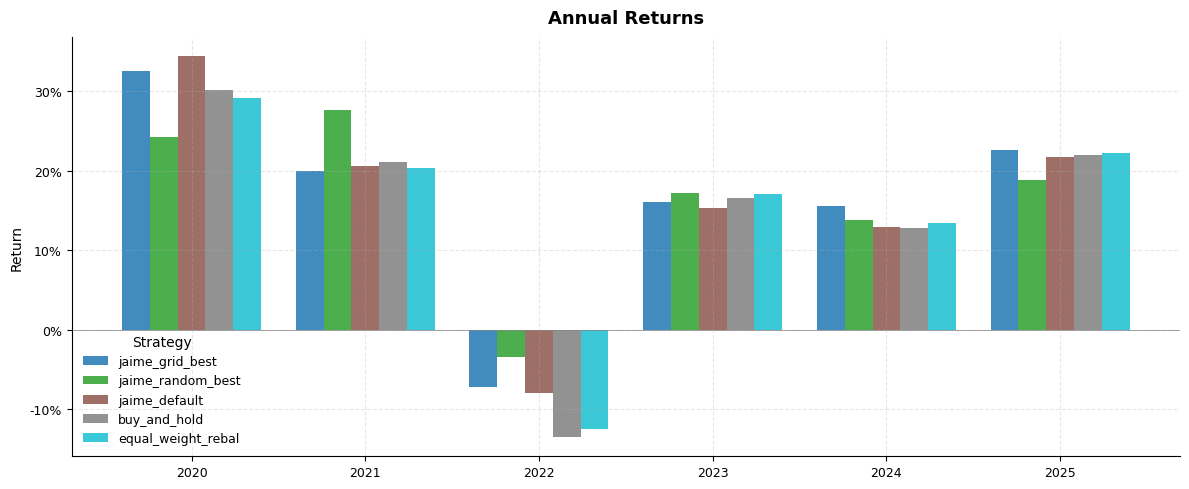

In [27]:
comparison.plot_value()
comparison.plot_drawdown()
comparison.plot_annual_returns()

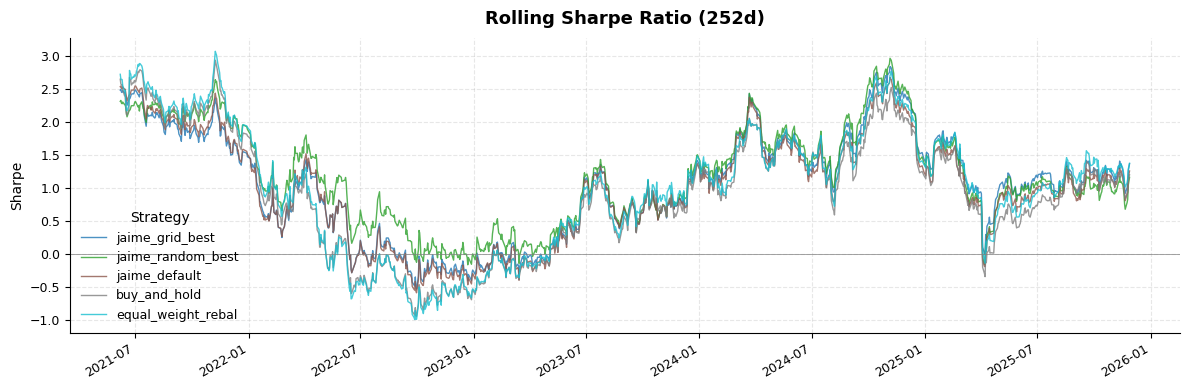

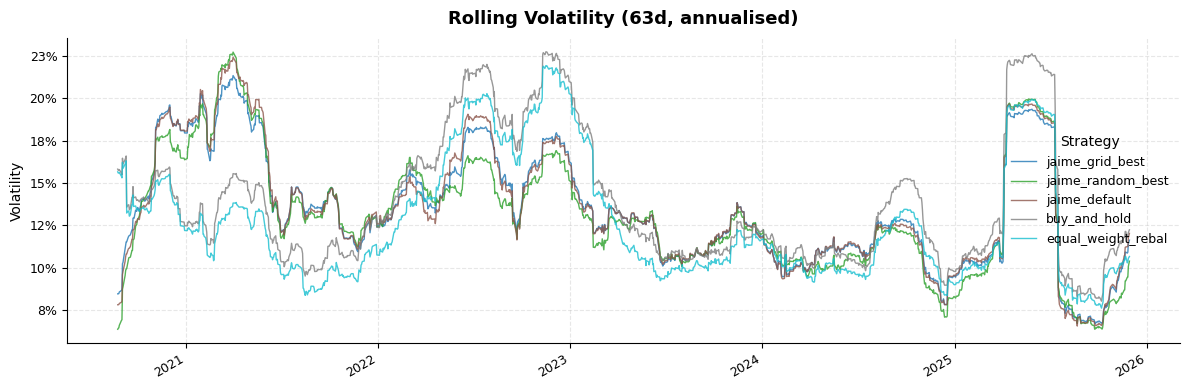

In [28]:
comparison.plot_rolling_sharpe()
comparison.plot_rolling_volatility()